# Using Simplicit's Easy API To Simulate Example Mesh
[Simplicits](https://research.nvidia.com/labs/toronto-ai/simplicits/) is a mesh-free, representation-agnostic way to simulation elastic deformations. 

Here's a simple way to use the simplicit's code base. We can create a simple object, train it, simulate it and visualize all in a very few lines of code via our `easy_api`.

In [ ]:
# !pip install -q k3d

In [1]:
import copy, math, os, sys, logging, threading
from typing import List, Tuple
from pathlib import Path

import numpy as np
import torch
import kaolin as kal


from IPython.display import display
from ipywidgets import Button, HBox, VBox

#local logger, prints at info or above
logging.basicConfig(level=logging.INFO, stream=sys.stdout)
logger = logging.getLogger(__name__)

#logger used in the api code
logging.getLogger('kaolin.physics').setLevel(logging.INFO) # Prints everything at debug level or above

sys.path.append(str(Path("..")))
from tutorial_common import COMMON_DATA_DIR

def sample_mesh_path(fname):
    return os.path.join(COMMON_DATA_DIR, 'meshes', fname)

def print_tensor(t, name='', **kwargs):
    print(kal.utils.testing.tensor_info(t, name=name, **kwargs))

## Loading Geometry
Simplicits works with any geometry: meshes, pointclouds, SDFs, Gaussian splats, and more. For this example, we will use a mesh:

In [2]:
# Import and triangulate to enable rasterization; move to GPU
mesh = kal.io.import_mesh(sample_mesh_path('fox.obj'), triangulate=True).cuda()
mesh.vertices = kal.ops.pointcloud.center_points(mesh.vertices.unsqueeze(0), normalize=True).squeeze(0) 
orig_vertices = mesh.vertices.clone()  # Also save original undeformed vertices
print(mesh)

SurfaceMesh object with batching strategy NONE
            vertices: [5002, 3] (torch.float32)[cuda:0]  
               faces: [10000, 3] (torch.int64)[cuda:0]  
             normals: [5002, 3] (torch.float32)[cuda:0]  
    face_normals_idx: [10000, 3] (torch.int64)[cuda:0]  
                 uvs: [5505, 2] (torch.float32)[cuda:0]  
        face_uvs_idx: [10000, 3] (torch.int64)[cuda:0]  
material_assignments: [10000] (torch.int16)[cuda:0]  
           materials: list of length 1
       face_vertices: if possible, computed on access from: (faces, vertices)
        face_normals: if possible, computed on access from: (normals, face_normals_idx) or (vertex_normals, faces) or (vertices, faces)
            face_uvs: if possible, computed on access from: (uvs, face_uvs_idx)
      vertex_normals: if possible, computed on access from: (faces, face_normals)
     vertex_tangents: if possible, computed on access from: (faces, face_vertices, face_uvs, vertex_normals)
       vertex_colors: if possi

## Sample Geometry
To enable simulation we need point samples within the object's volume, and physical material parameters per point. Lets set this up.

In [6]:
# Physics material parameters
soft_youngs_modulus = 1e5
poisson_ratio = 0.45
rho = 500  # kg/m^3
approx_volume = 0.5  # m^3

# Points sampled over the object's bounding box
num_samples = 1000000
uniform_pts = torch.rand(num_samples, 3, device='cuda') * (orig_vertices.max(dim=0).values - orig_vertices.min(dim=0).values) + orig_vertices.min(dim=0).values
boolean_signs = kal.ops.mesh.check_sign(mesh.vertices.unsqueeze(0), mesh.faces, uniform_pts.unsqueeze(0), hash_resolution=512)

# use pts within the object
pts = uniform_pts[boolean_signs.squeeze()]
yms = torch.full((pts.shape[0],), soft_youngs_modulus, device="cuda")
prs = torch.full((pts.shape[0],), poisson_ratio, device="cuda")
rhos = torch.full((pts.shape[0],), rho, device="cuda")

import k3d
plot = k3d.plot()
plot += k3d.points(pts.cpu().detach().numpy(), point_size=0.01)
plot.display()

Output()

## Create and Train a SimplicitsObject
We encapsulate everything Simplicits method needs to know about the simulated object in a `SimplicitsObject` instance. Once the object is created, we need to run training to learn reduced degrees of freedom our simulator can use. 

**This will take a couple of minutes.** Please be patient.

In [19]:
import kaolin.physics.simplicits.utils as simplicits_utils
# print(simplicits_utils.method)
# simplicits_utils.method = 'quad'
# print(simplicits_utils.method)
all_losses = {}
methods = ['lbs','dqlbs']


In [ ]:

for method in methods:
    #setting methods for transformation
    # simplicits_utils.method = method
    # Initialize and train a Simpicits object to enable simulation
    sim_obj = kal.physics.simplicits.SimplicitsObject(pts, yms, prs, rhos, torch.tensor([approx_volume], dtype=torch.float32, device="cuda"), num_handles=5,skining_method=method)
    # # print('Training simplicits object. This will take 2-3min. ')
    logs = sim_obj.train(num_steps=50000)  # TODO: with next patch add log_interval=1000
    all_losses[method]=logs
    # print(simplicits_utils.method)
    # print('Object ready to simulate.')
# sim_obj.load_model('fox_mesh_model_50k_steps_quad.pt') # if you saved previously trained object, you can load it instead

INFO:kaolin.physics.simplicits.easy_api:Training step: 0, le: 591.6830444335938, lo: 45311404.0


INFO:kaolin.physics.simplicits.easy_api:Training step: 1000, le: 3249.36474609375, lo: 80881.1015625
INFO:kaolin.physics.simplicits.easy_api:Training step: 2000, le: 3179.830810546875, lo: 41124.58984375
INFO:kaolin.physics.simplicits.easy_api:Training step: 3000, le: 4581.6572265625, lo: 41162.6953125
INFO:kaolin.physics.simplicits.easy_api:Training step: 4000, le: 8028.91162109375, lo: 5997.18115234375
INFO:kaolin.physics.simplicits.easy_api:Training step: 5000, le: 8080.79150390625, lo: 1924.3460693359375
INFO:kaolin.physics.simplicits.easy_api:Training step: 6000, le: 4246.63525390625, lo: 2116.994140625
INFO:kaolin.physics.simplicits.easy_api:Training step: 7000, le: 4043.730224609375, lo: 3531.535888671875
INFO:kaolin.physics.simplicits.easy_api:Training step: 8000, le: 5553.966796875, lo: 4867.38671875
INFO:kaolin.physics.simplicits.easy_api:Training step: 9000, le: 4756.02392578125, lo: 6014.2373046875
INFO:kaolin.physics.simplicits.easy_api:Training step: 10000, le: 5983.22216

FileNotFoundError: [Errno 2] No such file or directory: 'fox_mesh_model_50k_steps_quad.pt'

In [ ]:
# print(all_losses)

{'lbs': [(1295.1129150390625, 142330144.0)], 'dqlbs': [(6444023.5, 30575976.0)]}


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Build DataFrame
rows = []
for method, losses in all_losses.items():
    for step, (el, neo) in enumerate(losses):
        rows.append({"method": method, "step": step,
                     "elastic_loss": el, "neo_loss": neo})
df = pd.DataFrame(rows)

print(df.head())
df.to_csv('le_lo_lbs_quat_pdf.csv', index=False, encoding='utf-8')



  method  step  elastic_loss      neo_loss
0    lbs     0    591.683044  4.531140e+07
1    lbs     1   3249.364746  8.088110e+04
2    lbs     2   3179.830811  4.112459e+04
3    lbs     3   4581.657227  4.116270e+04
4    lbs     4   8028.911621  5.997181e+03


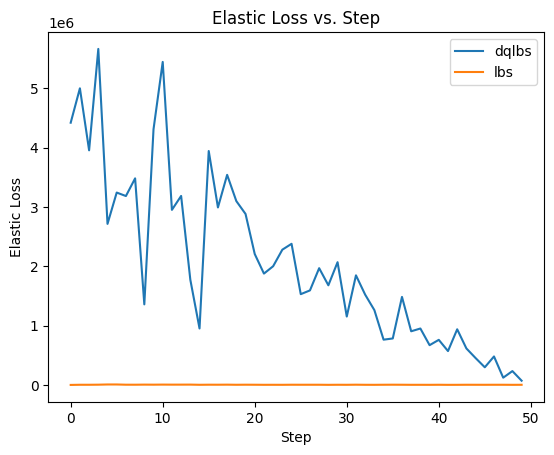

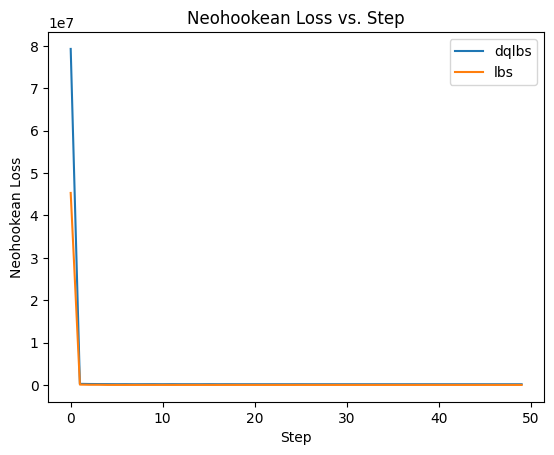

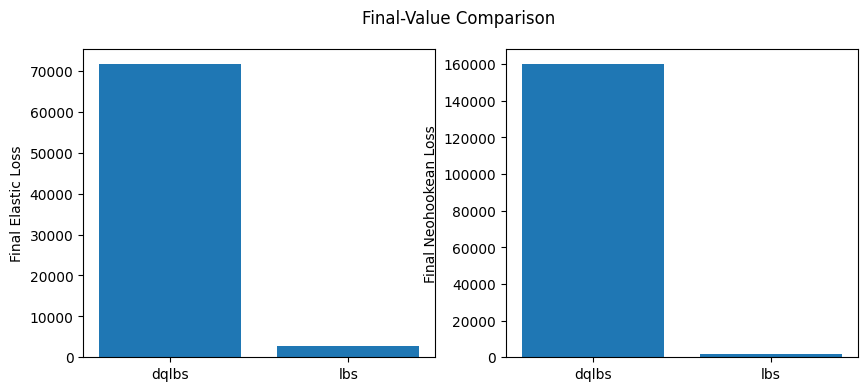

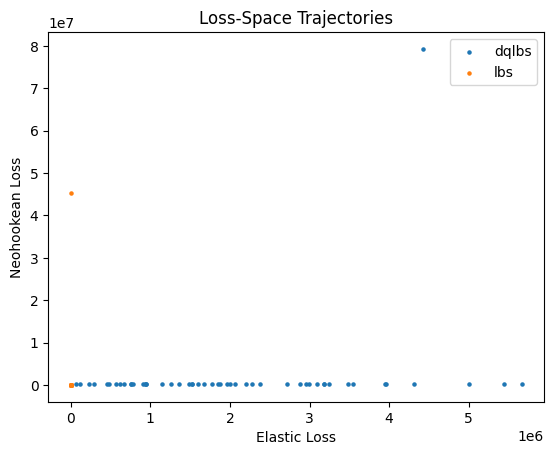

In [22]:
# 2. Line plot: elastic loss
df = pd.read_csv('le_lo_lbs_quat_pdf.csv')
plt.figure()
for m, grp in df.groupby("method"):
    plt.plot(grp.step, grp.elastic_loss, label=m)
plt.xlabel("Step")
plt.ylabel("Elastic Loss")
plt.legend()
plt.title("Elastic Loss vs. Step")

# 3. Line plot: neohookean loss
plt.figure()
for m, grp in df.groupby("method"):
    plt.plot(grp.step, grp.neo_loss, label=m)
plt.xlabel("Step")
plt.ylabel("Neohookean Loss")
plt.legend()
plt.title("Neohookean Loss vs. Step")

# 4. Final‐value bar chart
finals = df.groupby("method").agg(
    final_elastic=("elastic_loss", "last"),
    final_neo=("neo_loss", "last")
).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].bar(finals.method, finals.final_elastic)
ax[0].set_ylabel("Final Elastic Loss")
ax[1].bar(finals.method, finals.final_neo)
ax[1].set_ylabel("Final Neohookean Loss")
plt.suptitle("Final‐Value Comparison")

# 5. Scatter trajectory
plt.figure()
for m, grp in df.groupby("method"):
    plt.scatter(grp.elastic_loss, grp.neo_loss, s=5, label=m)
plt.xlabel("Elastic Loss")
plt.ylabel("Neohookean Loss")
plt.legend()
plt.title("Loss‐Space Trajectories")

plt.show()

In [ ]:
# Optionally, you can save/load this pre-trained object
# sim_obj.save_model('fox_mesh_model_10k_steps_quad.pt')

## Create a Scene
Now we are ready to set up all the forces in the scene to simulated as well as simulation settings. For example, here we will add gravity and a floor plane.

In [24]:
scene = kal.physics.simplicits.SimplicitsScene() # default empty scene
#Convergence might not be guaranteed with few newton iterations, but runs very fast
scene.max_newton_steps = 3

 The same `SimplicitsObject` can be added to multiple scene. Let's add it to our scene. Not we can reference it within the scene using `obj_idx`.

In [25]:
obj_idx = scene.add_object(sim_obj)

Lets set gravity and floor forces on the scene

In [ ]:
# print(simplicits_utils.method)

dual_quat


In [26]:
scene.set_scene_gravity(acc_gravity=torch.tensor([0, 9.8, 0]))
scene.set_scene_floor(floor_height=-0.8, floor_axis=1, floor_penalty=1000)

We can play around with the material parameters of the object, indicated via `object_idx`

In [27]:
scene.set_object_materials(obj_idx, yms=torch.tensor(1e3, device='cuda', dtype=torch.float))

## Set Up Rendering
Let's set up rendering of our mesh so we can view it in a notebook.

In [28]:
resolution = 512
camera = kal.render.easy_render.default_camera(resolution).cuda()

light_direction = kal.render.lighting.sg_direction_from_azimuth_elevation(1., 1.)
lighting = kal.render.lighting.SgLightingParameters(amplitude=3., sharpness=5., direction=light_direction).cuda()
    
def render(in_cam):
    # render
    active_pass=kal.render.easy_render.RenderPass.render
    render_res = kal.render.easy_render.render_mesh(in_cam, mesh, lighting=lighting)

    # create white background
    img = render_res[active_pass]
    background_mask = (render_res[kal.render.easy_render.RenderPass.face_idx] < 0).bool()
    img2 = torch.clamp(img, 0, 1)[0]
    img2[background_mask[0]] = 1
    final = (img2 * 255.).to(torch.uint8)
    return {"img":final, "face_idx": render_res[kal.render.easy_render.RenderPass.face_idx].squeeze(0).unsqueeze(-1)}

# faster low-res render during mouse motion
def fast_render(in_cam, factor=8):
    lowres_cam = copy.deepcopy(in_cam)
    lowres_cam.width = in_cam.width // factor
    lowres_cam.height = in_cam.height // factor
    return render(lowres_cam)

## That's it! Let's Run and View or Physics Simulation
All we need to do now is run simulation and display the object using Kaolin's in-notebook visualizer.

In [29]:
import imageio
import numpy as np
from PIL import Image
from IPython.display import FileLink, display
import threading
# import kaolin.render.lighting.sg as _sg
# _sg.USE_JIT = False

# storage for frames
frames = []
recording = True   # set True to record every frame, False to disable


In [30]:
from IPython.display import FileLink, display
import imageio, numpy as np
from PIL import Image

def save_recordings():
    if not frames:
        print("No frames to save!")
        return

    # GIF
    gif_path = 'simulation_demo.gif'
    print(f"Saving GIF → {gif_path}")
    imageio.mimsave(gif_path, frames, fps=15)

    # MP4
    mp4_path = 'simulation_demo.mp4'
    print(f"Saving MP4 → {mp4_path}")
    writer = imageio.get_writer(mp4_path, fps=15)  # now backed by ffmpeg
    for frm in frames:
        writer.append_data(np.array(frm))
    writer.close()

    # Links
    display(FileLink(gif_path))
    display(FileLink(mp4_path))


In [31]:
def run_sim():
    global frames
    frames = []             # clear old frames
    scene.reset()           # reset simulation

    for s in range(100):
        # advance simulation
        scene.run_sim_step()

        # update mesh for visualizer
        mesh.vertices = scene.get_object_deformed_pts(obj_idx, orig_vertices).squeeze()

        # render update on screen
        visualizer.render_update()

        # if recording, grab the latest frame
        if recording:
            out = visualizer.render(visualizer.camera)
            img_t = out['img'] if isinstance(out, dict) else out
            img_np = (img_t.cpu().numpy() * 255).astype(np.uint8)
            frames.append(Image.fromarray(img_np))

    # once done, save to disk & display download links
    save_recordings()


In [32]:
from ipywidgets import Button, HBox

# Start the thread
def start_simulation(_):
    threading.Thread(target=run_sim, daemon=True).start()

# Button
btn = Button(description='Run & Record Sim')
btn.on_click(start_simulation)

# Your existing visualizer setup
visualizer = kal.visualize.IpyTurntableVisualizer(
    resolution, resolution,
    copy.deepcopy(camera),
    render,
    fast_render=fast_render,
    max_fps=24, world_up_axis=1
)
visualizer.render_update()

display(HBox([visualizer.canvas, btn]), visualizer.out)


/home/alonot/Anup_oelp/kaolin/kaolin/render/easy_render/mesh.py:282: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  im_bitangents = torch.nn.functional.normalize(torch.cross(im_tangents, im_base_normals), dim=-1)
/home/alonot/Anup_oelp/kaolin_env/lib/python3.9/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Output()

Saving GIF → simulation_demo.gif
Saving MP4 → simulation_demo.mp4


/home/alonot/Anup_oelp/kaolin/examples/tutorial/physics/simulation_demo.gif

/home/alonot/Anup_oelp/kaolin/examples/tutorial/physics/simulation_demo.mp4

Saving GIF → simulation_demo.gif
Saving MP4 → simulation_demo.mp4


/home/alonot/Anup_oelp/kaolin/examples/tutorial/physics/simulation_demo.gif

/home/alonot/Anup_oelp/kaolin/examples/tutorial/physics/simulation_demo.mp4

In [ ]:
# Reset mesh to its rest state
mesh.vertices = orig_vertices

fox_verts = []

global sim_thread_open, sim_thread
sim_thread_open = False
sim_thread = None

def run_sim():
    scene.reset()  # reset internal simultion state

    for s in range(100):
        with visualizer.out:
            scene.run_sim_step()
            print(".", end="")
        mesh.vertices = scene.get_object_deformed_pts(obj_idx, orig_vertices).squeeze()
        if s%10 == 0:
            fox_verts.append(mesh.vertices.clone().detach())
        visualizer.render_update()

def start_simulation(b):
    global sim_thread_open, sim_thread
    with visualizer.out:
        if(sim_thread_open):
            sim_thread.join()
            sim_thread_open = False
        sim_thread_open = True
        sim_thread = threading.Thread(target=run_sim, daemon=True)
        sim_thread.start()

scene.reset_object(obj_idx)
button = Button(description='Run Sim')
button.on_click(start_simulation)
visualizer = kal.visualize.IpyTurntableVisualizer(
    resolution, resolution, copy.deepcopy(camera), render, fast_render=fast_render,
    max_fps=24, world_up_axis=1)
visualizer.render_update()  # render first frame
display(HBox([visualizer.canvas, button]), visualizer.out)